In [11]:
import torch
from components.datasets import load_dataset
from components.models import init_mf_params, create_anfis_model
from components.trainer import train_model

# Config
config = {
    "dataset": "iris", # options: mackey-glass, circles, spiral, moons, swiss-roll, iris
    "mf_type": "advanced", # options: simple, advanced
    "mf_init": "fcm", # options: fcm, random_uniform
    "K": 7,
    "s_mode": "alpha_beta",
    "n_epochs": 1000,
    "lr": 0.001,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}

# 1) Load dataset
X_train, X_test, y_train, y_test, task_type, n_outputs = load_dataset(config["dataset"])

# 2) Initialize MF
centers_init, spreads_init = init_mf_params(
    X_train, K=config["K"], method=config["mf_init"], scale=1.0, seed=config["seed"]
)

# 3) Create model
model = create_anfis_model(
    config["mf_type"], centers_init, spreads_init, n_outputs=n_outputs, s_mode=config["s_mode"]
).to(config["device"])




Final Results:
Mode: alpha_beta
Train: accuracy rate 0.983 (118/120) | error 0.017 (2)
Test: accuracy rate 1.000 (30/30) | error 0.000 (0)

Per-rule, per-feature MF contributions and raw participation:
Rule 0, Feature 0: Raw weight -> Gaussian=0.7597, Sigmoid=0.2403
Rule 0, Feature 1: Raw weight -> Gaussian=0.8046, Sigmoid=0.1954
Rule 0, Feature 2: Raw weight -> Gaussian=0.5273, Sigmoid=0.4727
Rule 0, Feature 3: Raw weight -> Gaussian=0.5630, Sigmoid=0.4370
Rule 1, Feature 0: Raw weight -> Gaussian=0.8143, Sigmoid=0.1857
Rule 1, Feature 1: Raw weight -> Gaussian=0.8283, Sigmoid=0.1717
Rule 1, Feature 2: Raw weight -> Gaussian=0.8174, Sigmoid=0.1826
Rule 1, Feature 3: Raw weight -> Gaussian=0.8096, Sigmoid=0.1904
Rule 2, Feature 0: Raw weight -> Gaussian=0.4488, Sigmoid=0.5512
Rule 2, Feature 1: Raw weight -> Gaussian=0.4783, Sigmoid=0.5217
Rule 2, Feature 2: Raw weight -> Gaussian=0.5959, Sigmoid=0.4041
Rule 2, Feature 3: Raw weight -> Gaussian=0.4885, Sigmoid=0.5115
Rule 3, Feature 0

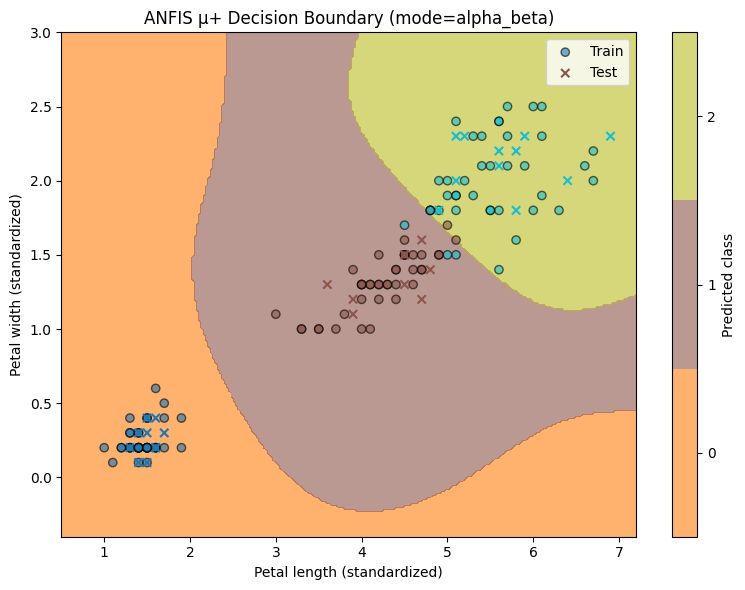

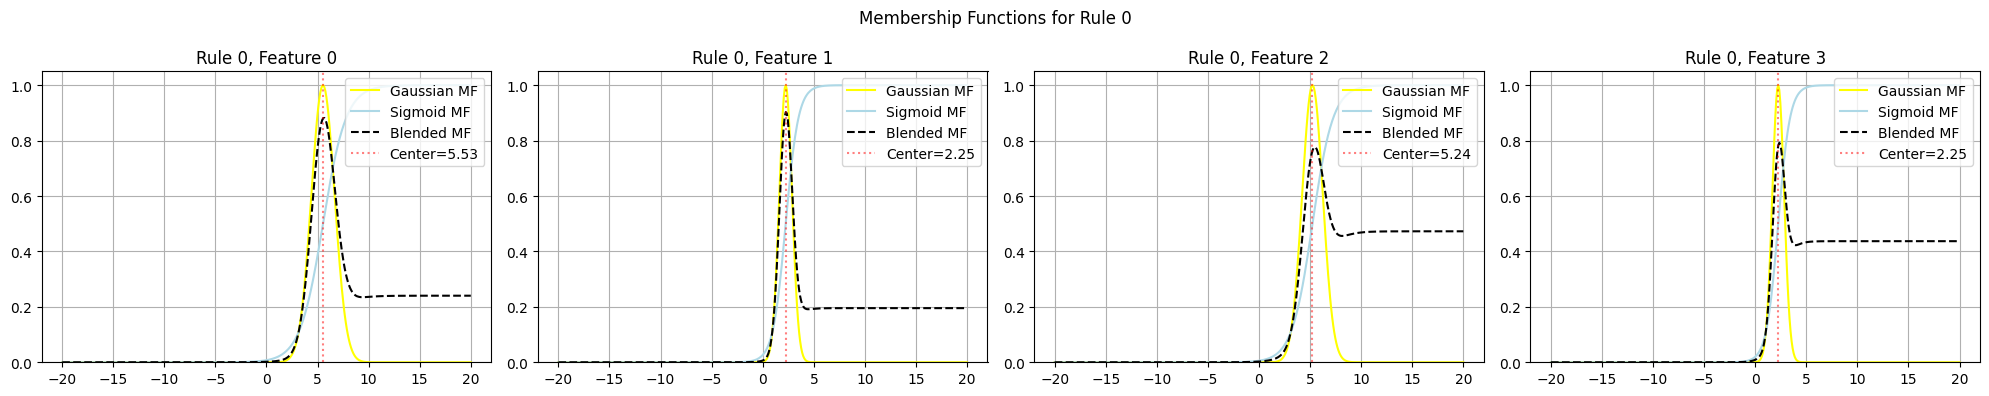

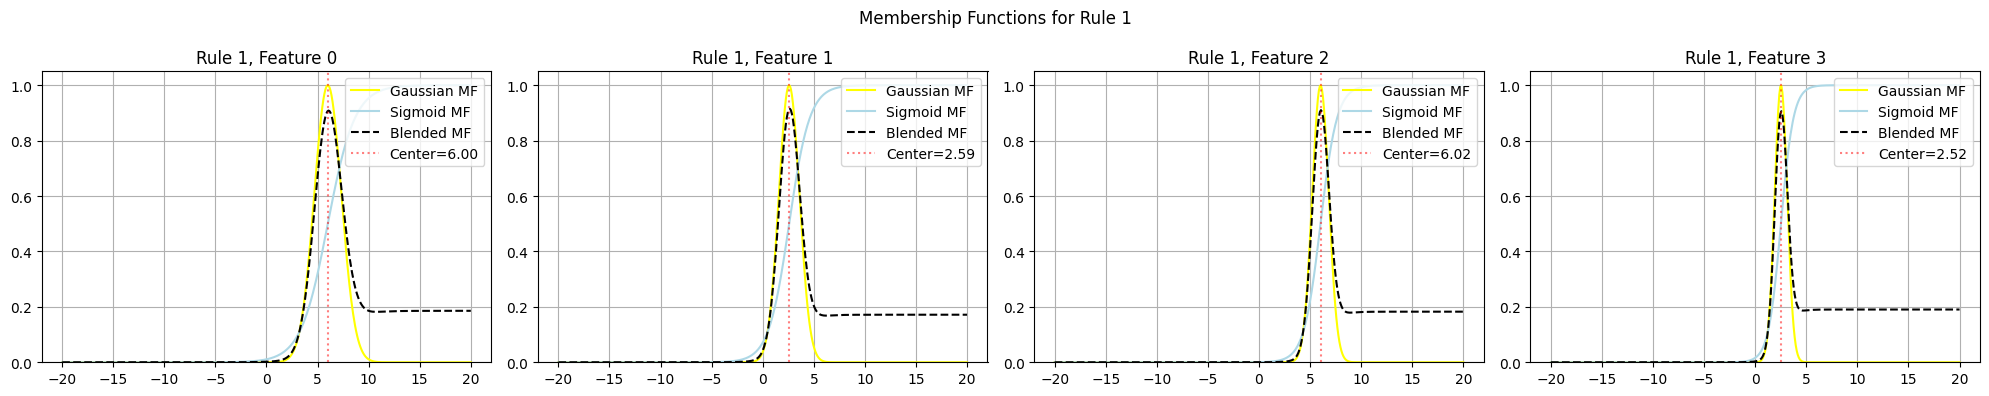

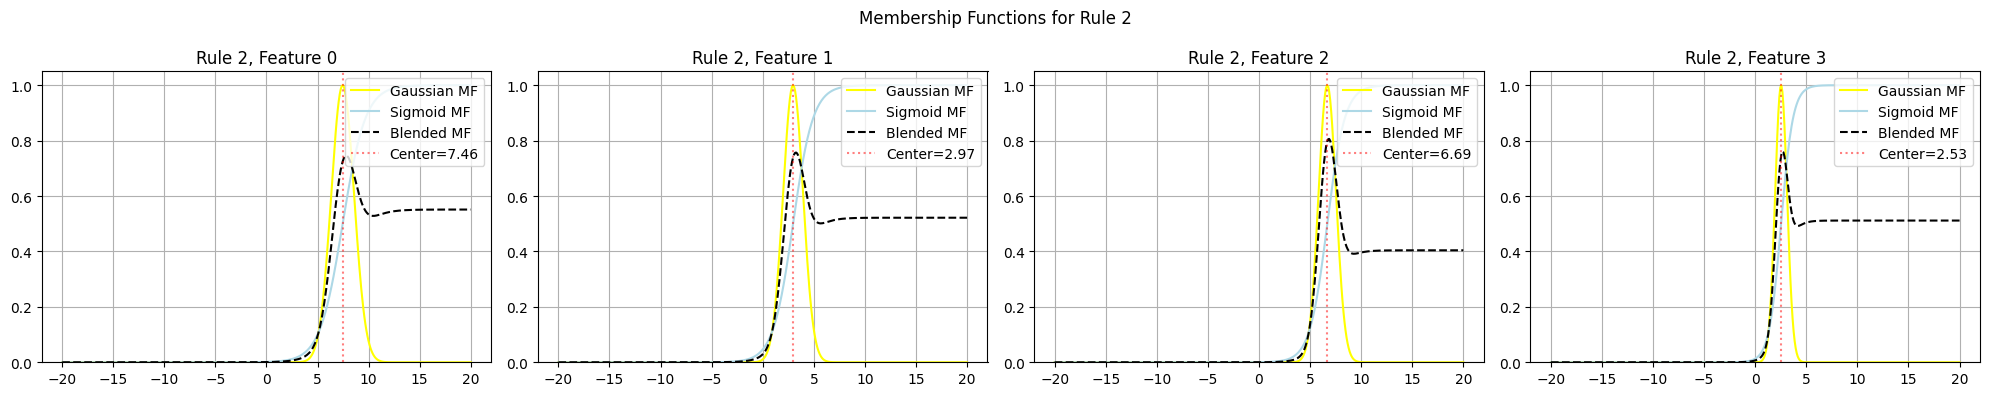

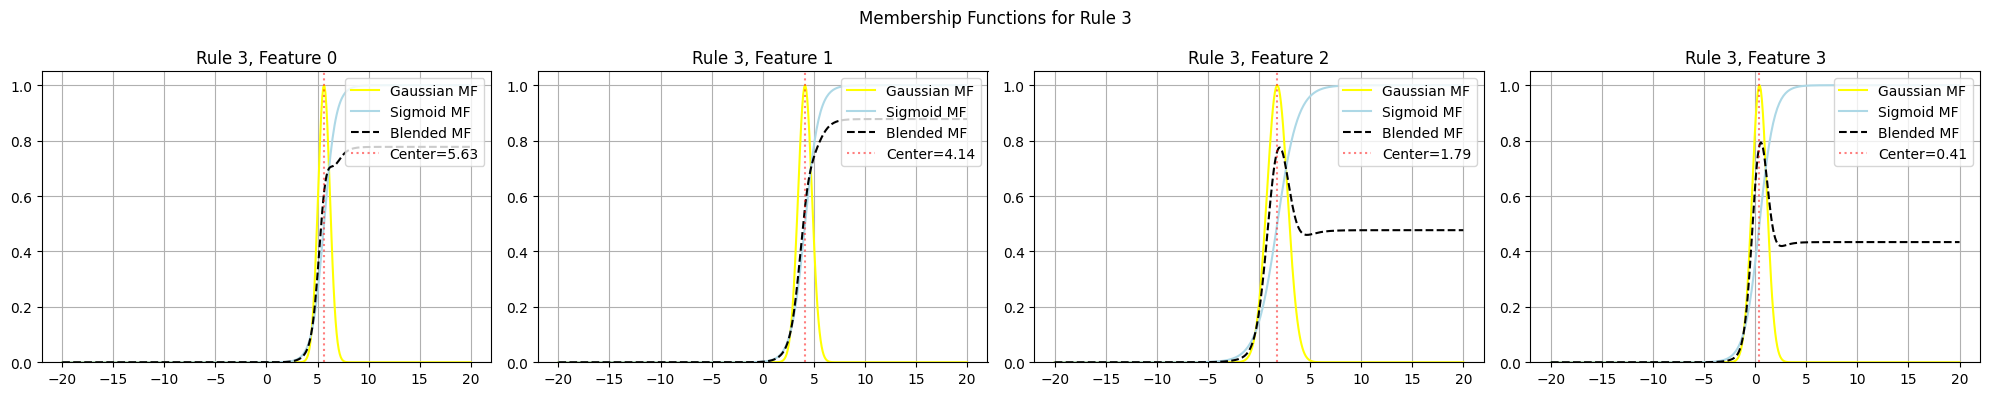

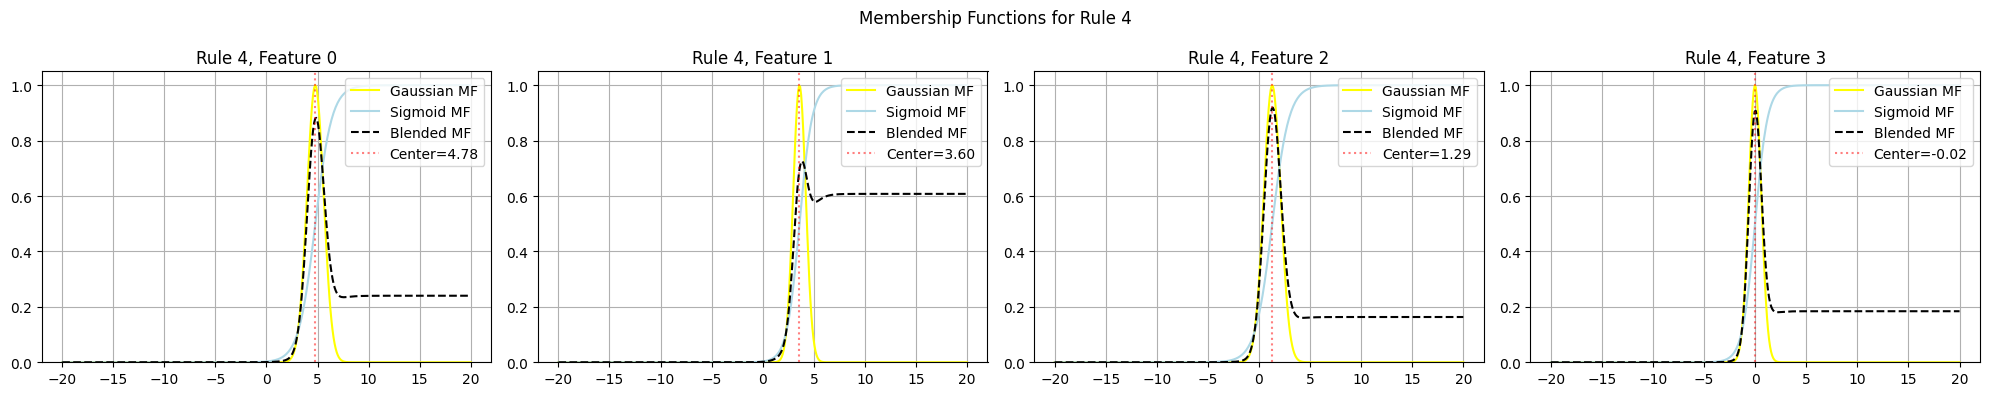


Note: Showing only first 5 rules out of 7 total rules.


In [12]:
from components.utils import evaluate_anfis_model

# 4) Train
model = train_model(
    model, X_train, y_train, X_test, y_test,
    task_type=task_type, n_epochs=config["n_epochs"], lr=config["lr"], device=config["device"]
)


# 5) Evaluate and plot results
# For iris dataset
evaluate_anfis_model(
    model, X_train, y_train, X_test, y_test, 
    device=config["device"], 
    s_mode_choice=config["s_mode"], 
    centers_init=centers_init,
    dataset_name=config["dataset"] 
)